# FLIM Analysis of EGFP and Maroon: Isolated Protein and Transiently Expressed in U2OS

## Loading Necessary Script

In [1]:
import os
import sys
import io
import numpy as np
import scipy.optimize as optimize
import matplotlib.pyplot as plt

import pq_decoding_functions as pq
import flim_fitting_functions as fit

## EGFP
### Transient Expression


Assigned photons to pixels.
 2.045902985461769 % of photons were out of range... Total: 147102 of 7190077 photons.


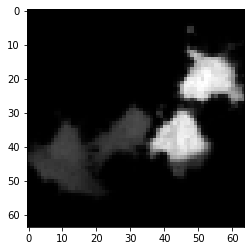

In [2]:
EGFP_cell_data, EGFP_cell_meta = pq.readPTUData(
    path = '../../../FLIM Data/Praktikum_Biochemie/raw_data/FP_EGFP_Maroon_200312.sptw/200312_EGFP_1_1_1.ptu'
)

EGFP_cell_flimarray, EGFP_image = pq.buildFLIMArray(
    recordarray = EGFP_cell_data,
    channel = 1,
    linesinfile = pq.countLines(EGFP_cell_data),
    pixelsx = EGFP_cell_meta['PixelsX'],
    pixelsy = EGFP_cell_meta['PixelsY'],
    globRes = EGFP_cell_meta['GlobalResolution'],
    timeRes = EGFP_cell_meta['Resolution'],
    spatialBinning = 3,
    temporalBinning = 0
)

plt.imshow(EGFP_image, cmap = 'gray')
plt.show()

In [3]:
time_axis = fit.make_time_axis(
    EGFP_cell_meta['GlobalResolution'],
    EGFP_cell_meta['Resolution'],
    EGFP_cell_flimarray.shape[2]
)

EGFP_decay = fit.sum_up_decay(EGFP_cell_flimarray)

In [ ]:
EGFP_fit = 